# Portfolio Optimization

This is the core of the project. The question is: given these four stocks, how should you split your money between them to get the best return for a given level of risk?

Modern Portfolio Theory (MPT) may help. The idea is that risk isn't just about how volatile a single stock is — it's about how the stocks move relative to each other. A stock that zigs when others zag can actually reduce your overall portfolio risk, even if it's volatile on its own.

## 1. Preparation

In [10]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.dpi'] = 120

TICKER_LABELS = {
    'MC.PA'   : 'LVMH',
    'ITX.MC'  : 'Inditex',
    'HM-B.ST' : 'H&M',
    'TPR'     : 'Tapestry',
}

prices = pd.read_csv('data/prices.csv', index_col=0, parse_dates=True)
prices.columns = [TICKER_LABELS.get(c, c) for c in prices.columns]

print(prices.shape)
prices.tail(3)

(1550, 4)


,H&M,Inditex,LVMH,Tapestry
Date,,,,
2025-12-26,184.100006,56.080002,632.099976,130.948929
2025-12-29,186.149994,56.220001,633.200012,129.991486
2025-12-30,185.899994,56.619999,639.299988,129.183655


## 2. The math behind MPT (expected return, covariance, Sharpe ratio)

### Expected return

For a portfolio with weights $\mathbf{w} = [w_1, w_2, \ldots, w_n]^T$ where $\sum_i w_i = 1$ and $w_i \geq 0$, the expected return is:

$$E[R_p] = \mathbf{w}^T \boldsymbol{\mu} = \sum_{i=1}^{n} w_i \mu_i$$

where $\mu_i = 252 \cdot \overline{r_i}$ is the annualized mean daily log return for asset $i$.

### Covariance matrix

The covariance matrix $\Sigma \in \mathbb{R}^{n \times n}$ captures how each pair of assets moves together:

$$\Sigma_{ij} = \text{Cov}(R_i, R_j) = \frac{1}{T-1} \sum_{t=1}^{T}(r_{i,t} - \mu_i)(r_{j,t} - \mu_j)$$

The diagonal entries $\Sigma_{ii} = \sigma_i^2$ are the individual asset variances. Off-diagonal entries measure co-movement - low or negative values between two assets mean they partially cancel each other out, which is the mechanism behind diversification.

### Portfolio variance

Because of those off-diagonal terms, portfolio variance is not just the weighted average of individual variances:

$$\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w} = \sum_{i=1}^{n}\sum_{j=1}^{n} w_i w_j \Sigma_{ij}$$

This is what makes MPT non-trivial: adding a volatile asset to a portfolio can reduce overall risk if its covariance with the existing assets is low enough.

### Sharpe ratio

The Sharpe ratio measures return per unit of risk, adjusted for the risk-free rate $R_f$:

$$S = \frac{E[R_p] - R_f}{\sigma_p}$$

A higher Sharpe ratio means more return for the same amount of risk. The portfolio that maximizes $S$ sits on the tangency point of the Efficient Frontier — it's the "best" portfolio under the MPT framework given no view on absolute return targets.

### The optimization problem

Finding the min-variance and max-Sharpe portfolios is a constrained optimization problem:

Min-variance:
$$\min_{\mathbf{w}} \quad \mathbf{w}^T \Sigma \mathbf{w} \qquad \text{s.t.} \quad \mathbf{1}^T\mathbf{w} = 1, \quad w_i \geq 0$$

Max-Sharpe (equivalently, minimize negative Sharpe):
$$\min_{\mathbf{w}} \quad -\frac{\mathbf{w}^T \boldsymbol{\mu} - R_f}{\sqrt{\mathbf{w}^T \Sigma \mathbf{w}}} \qquad \text{s.t.} \quad \mathbf{1}^T\mathbf{w} = 1, \quad w_i \geq 0$$

Both are solved with scipy.optimize.minimize using the SLSQP method, which handles nonlinear objectives with equality and inequality constraints.

For a four-stock portfolio over a 6-year period, MPT is the right level of complexity.

In [11]:
daily_log_returns = np.log(prices / prices.shift(1)).dropna()

# Annualized expected returns and covariance matrix
mu    = daily_log_returns.mean() * 252
sigma = daily_log_returns.cov()  * 252

print('Annualized expected returns:')
print(mu.round(4).to_string())
print('Covariance matrix:')
print(sigma.round(6))

Annualized expected returns:
H&M         0.0301
Inditex     0.1271
LVMH        0.0846
Tapestry    0.2780
Covariance matrix:
               H&M   Inditex      LVMH  Tapestry
H&M       0.131069  0.061757  0.047060  0.064580
Inditex   0.061757  0.079228  0.040305  0.050587
LVMH      0.047060  0.040305  0.090837  0.056985
Tapestry  0.064580  0.050587  0.056985  0.243880


## 3. Monte Carlo simulation to map out the Efficient Frontier

The Efficient Frontier is the set of portfolios that give the highest possible return for each level of risk. There's no closed-form solution for the whole curve, so the standard approach is Monte Carlo - generate a large number of random weight combinations and plot them in (risk, return) space. The frontier naturally emerges as the upper edge of the point cloud.

I'm using 50,000 random portfolios here, which is enough to get a smooth-looking frontier with four assets.

In [12]:
N_PORTFOLIOS = 50_000
N_ASSETS     = len(prices.columns)
RF_RATE      = 0.04   # approximate risk-free rate over the period

mc_returns = np.zeros(N_PORTFOLIOS)
mc_vols    = np.zeros(N_PORTFOLIOS)
mc_sharpes = np.zeros(N_PORTFOLIOS)
mc_weights = np.zeros((N_PORTFOLIOS, N_ASSETS))

mu_arr    = mu.values
sigma_arr = sigma.values

for i in range(N_PORTFOLIOS):
    w = np.random.dirichlet(np.ones(N_ASSETS))   # random weights that sum to 1
    r = w @ mu_arr
    v = np.sqrt(w @ sigma_arr @ w)
    mc_returns[i] = r
    mc_vols[i]    = v
    mc_sharpes[i] = (r - RF_RATE) / v
    mc_weights[i] = w

print(f'Simulated {N_PORTFOLIOS:,} portfolios.')
print(f'Return range : {mc_returns.min():.3f} → {mc_returns.max():.3f}')
print(f'Vol range    : {mc_vols.min():.3f} → {mc_vols.max():.3f}')
print(f'Sharpe range : {mc_sharpes.min():.3f} → {mc_sharpes.max():.3f}')

Simulated 50,000 portfolios.
Return range : 0.034 → 0.274
Vol range    : 0.248 → 0.487
Sharpe range : -0.018 → 0.503


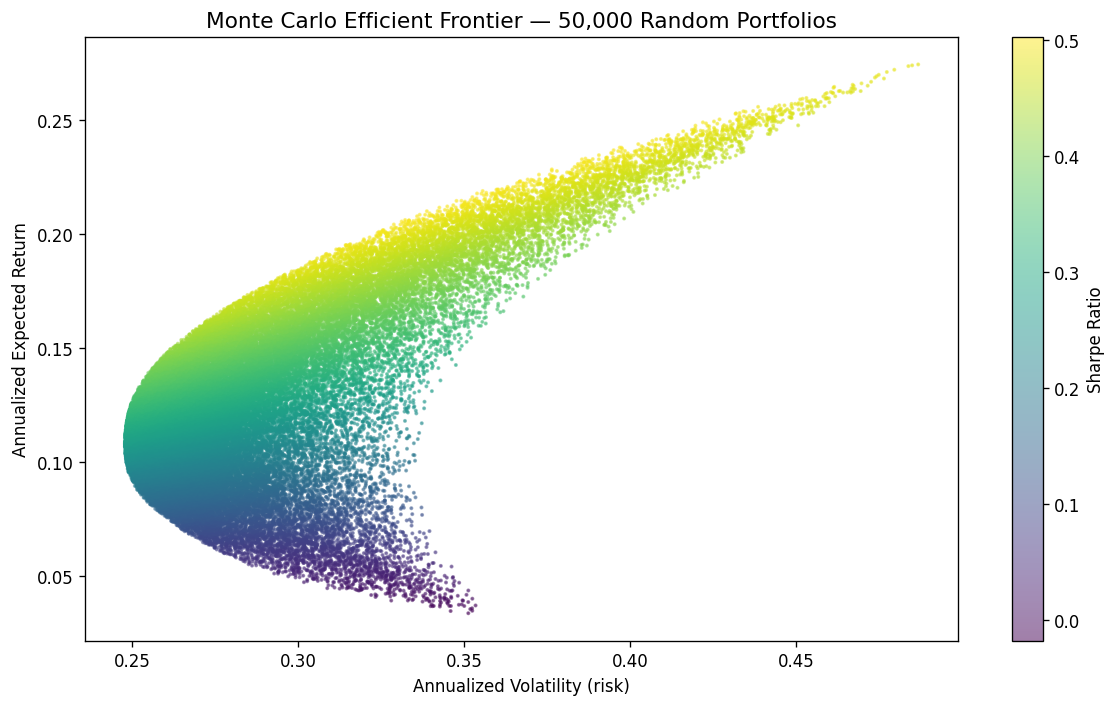

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    mc_vols, mc_returns,
    c=mc_sharpes, cmap='viridis',
    s=2, alpha=0.5
)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

ax.set_xlabel('Annualized Volatility (risk)')
ax.set_ylabel('Annualized Expected Return')
ax.set_title('Monte Carlo Efficient Frontier — 50,000 Random Portfolios', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Optimization - Min-Variance and Max-Sharpe

Monte Carlo shows the shape of the frontier but doesn't give us the exact optimal portfolios. For that I'm using scipy.optimize.minimize, which can solve the constrained optimization problem precisely.

Min-variance portfolio: minimize $\mathbf{w}^T \Sigma \mathbf{w}$ subject to $\sum_i w_i = 1$ and $w_i \geq 0$

Max-Sharpe portfolio: scipy minimizes by default, so I minimize the negative Sharpe ratio, which is equivalent to maximizing it.

In [19]:
def portfolio_stats(weights, mu, sigma, rf=RF_RATE):
    ret = weights @ mu
    volume = np.sqrt(weights @ sigma @ weights)
    sharpe = (ret - rf) / volume
    return ret, volume, sharpe


constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(N_ASSETS))
w0 = np.ones(N_ASSETS)/N_ASSETS 

res_minvar =  minimize ( lambda w: np.sqrt(w @ sigma @ w), w0, method='SLSQP', bounds=bounds, constraints=constraints)

w_minvar = res_minvar.x

print (f'Minimum-variance portfolio weights:{res_minvar.success}')

res_maxsharpe = minimize ( lambda w: -((w @ mu - RF_RATE) / np.sqrt(w @ sigma @ w)), w0, 
                          method='SLSQP',
                          bounds=bounds, 
                          constraints=constraints)

w_maxsharpe = res_maxsharpe.x

print (f'Maximum-Sharpe portfolio weights:{res_maxsharpe.success}')


Minimum-variance portfolio weights:True
Maximum-Sharpe portfolio weights:True


In [20]:
r_mv, v_mv, s_mv     = portfolio_stats(w_minvar,    mu_arr, sigma_arr)
r_ms, v_ms, s_ms     = portfolio_stats(w_maxsharpe, mu_arr, sigma_arr)
r_ew, v_ew, s_ew     = portfolio_stats(w0,          mu_arr, sigma_arr)

labels  = prices.columns.tolist()
summary = pd.DataFrame({
    'Equal Weight'  : w0,
    'Min Variance'  : w_minvar,
    'Max Sharpe'    : w_maxsharpe,
}, index=labels).T

summary['Return'] = [r_ew, r_mv, r_ms]
summary['Vol']    = [v_ew, v_mv, v_ms]
summary['Sharpe'] = [s_ew, s_mv, s_ms]

print(summary.round(4))

                 H&M  Inditex    LVMH  Tapestry  Return     Vol  Sharpe
Equal Weight  0.2500   0.2500  0.2500    0.2500  0.1299  0.2724  0.3301
Min Variance  0.0774   0.4900  0.3952    0.0374  0.1084  0.2478  0.2760
Max Sharpe    0.0000   0.3887  0.0000    0.6113  0.2193  0.3566  0.5029


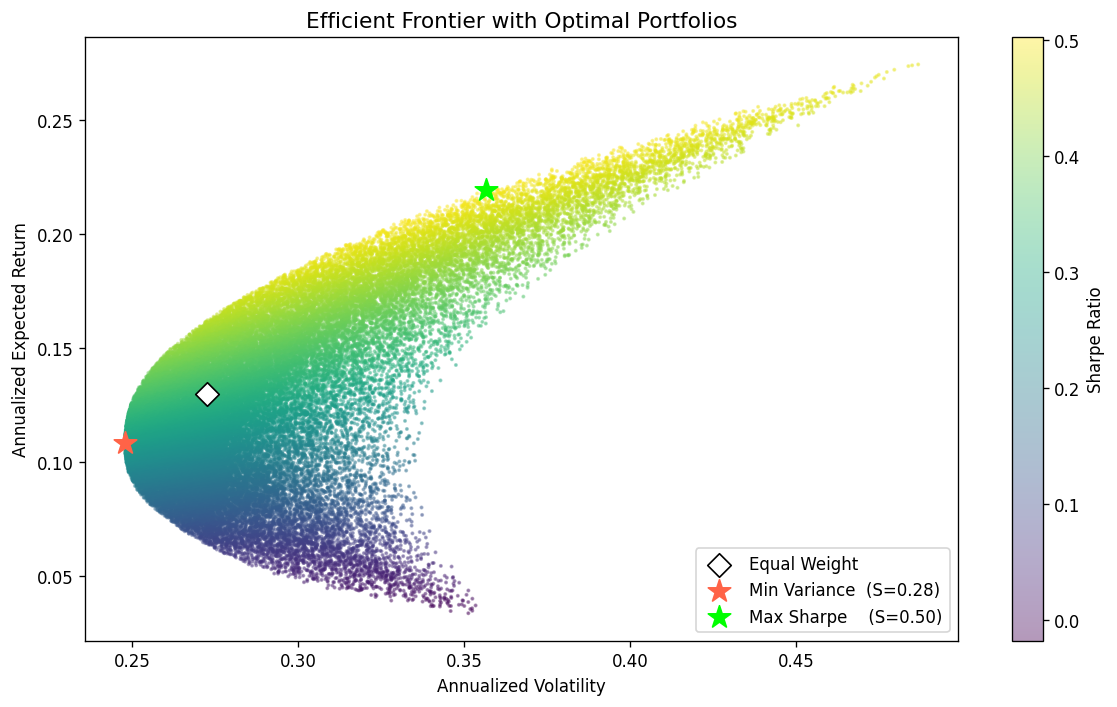

In [21]:
# optimal portfolios on top of the frontier
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(mc_vols, mc_returns, c=mc_sharpes, cmap='viridis', s=2, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

ax.scatter(v_ew, r_ew, marker='D', color='white',  edgecolors='black', s=100, zorder=5, label='Equal Weight')
ax.scatter(v_mv, r_mv, marker='*', color='tomato',  s=200, zorder=5, label=f'Min Variance  (S={s_mv:.2f})')
ax.scatter(v_ms, r_ms, marker='*', color='lime',    s=200, zorder=5, label=f'Max Sharpe    (S={s_ms:.2f})')

ax.set_xlabel('Annualized Volatility')
ax.set_ylabel('Annualized Expected Return')
ax.set_title('Efficient Frontier with Optimal Portfolios', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

          Equal Weight  Min Variance  Max Sharpe
H&M               0.25        0.0774      0.0000
Inditex           0.25        0.4900      0.3887
LVMH              0.25        0.3952      0.0000
Tapestry          0.25        0.0374      0.6113


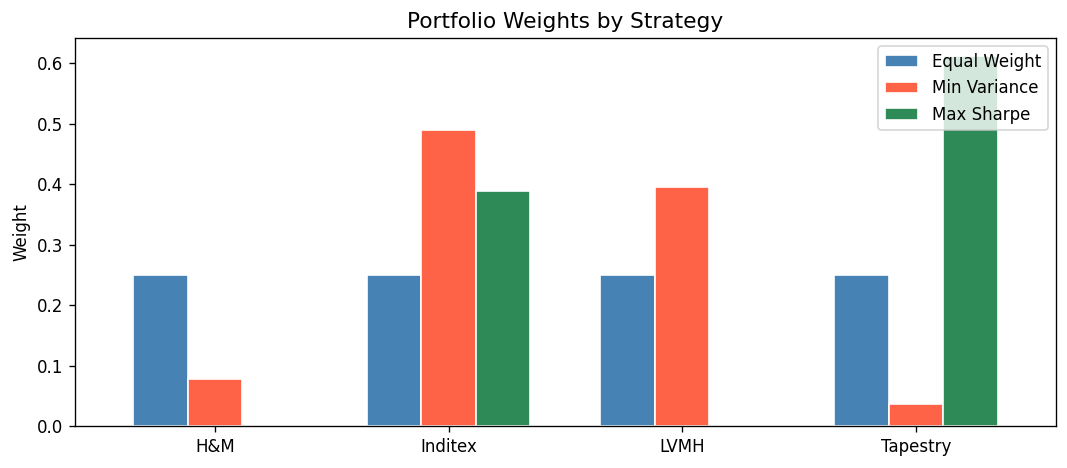

In [22]:
weight_df = pd.DataFrame({
    'Equal Weight' : w0,
    'Min Variance' : w_minvar,
    'Max Sharpe'   : w_maxsharpe,
}, index=labels)

print(weight_df.round(4))
weight_df.plot(
    kind='bar',
    figsize=(9, 4),
    color=['steelblue', 'tomato', 'seagreen'],
    edgecolor='white',
    width=0.7,
)
plt.title('Portfolio Weights by Strategy', fontsize=13)
plt.ylabel('Weight')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Assumptions and limitations: 

1. Static weights. 

- Both optimized portfolios hold fixed weights over the full period. In practice the optimal weights would drift as the return and covariance estimates updated. I think rolling-window optimization or Black-Litterman would be more realistic approaches.

2. Transaction costs ignored 
- Rebalancing to the static weights each period has real costs in practice. For a 4-stock portfolio they are small, but they would reduce realized Sharpe ratios relative to the theoretical values computed here.